### Lab 01b: Binary Linear Classifier

In this lab you will try making a binary linear classifier using the [Palmer Penguins dataset](https://allisonhorst.github.io/palmerpenguins/).

In [ ]:
!pip install palmerpenguins

In [ ]:
import sklearn
from palmerpenguins import load_penguins
from mlxtend.plotting import plot_decision_regions

The dataset is loaded as a [Pandas dataframe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).  

In [ ]:
df = load_penguins()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


For simplicity we will drop any rows with missing values (encoded as NaNs).

In [ ]:
df.dropna(inplace=True)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


Let's select just the Adelie and Chinstrap penguins.

In [ ]:
df = df[(df['species']=='Adelie')|(df['species']=='Chinstrap')]

Now we will grab the flipper length and bill length to be the features (stored in ``X``) and the species as the labels (stored in ``y``).

In [ ]:
X = df[['flipper_length_mm','bill_length_mm']].values
y = df['species'].map({'Adelie':0,'Chinstrap':1}).values

## Exercises

1. Fit a binary linear classifier using scikit-learn (see ``sklearn.linear_model.LogisticRegression``).

Plot the resulting classifier using ``plot_decision_regions(X, y, clf=model)``.


<Axes: >

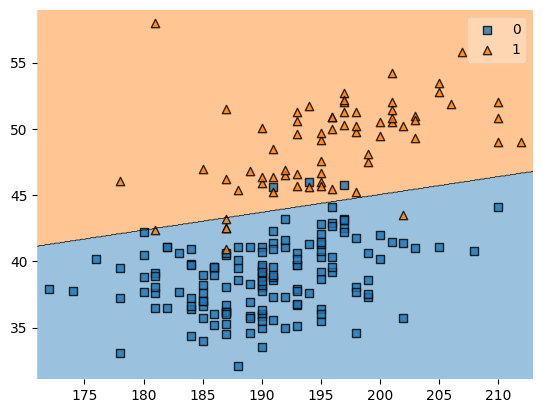

In [ ]:
model = sklearn.linear_model.LogisticRegression(random_state=0).fit(X, y)
plot_decision_regions(X, y, clf=model)

2. Print out the coefficients of the line (``model.coef_``).  Interpret these values (in terms of the direction of the line and also what they tell us about how the classifier operates).

In [ ]:
model.coef_

array([[-0.15845623,  1.17936568]])

Since the first is negative it means that flipper length has an inverse relationship with penguin species. The magnitude of the weight is small showing it has a weaker relationship. The second weight has a stronger positive relationship. This means that bill length is more "important" to the classifier in deciding species.

3. Calculate and print out the accuracy of the classifier using the `.score` function.  Interpret this value.

In [ ]:
model.score(X, y)

0.9579439252336449

The score function returns the r-squared value of the classifier. A score of .95 indicates that the classifier is good at determining penguin species. It also shows that our features explain variance well.

4. Try different combinations of features and print out the accuracy for each one.  Interpret your results.

In [68]:
X_1 = df[['bill_depth_mm','body_mass_g']].values
model_1 = sklearn.linear_model.LogisticRegression(random_state=0).fit(X_1, y)
model_1.score(X_1, y)

0.6822429906542056

Using bill depth and body mass the model produced an r-squared value of .68 which indicates that these features are not as good at predicting penguin species as flipper length and bill length.

0.9719626168224299

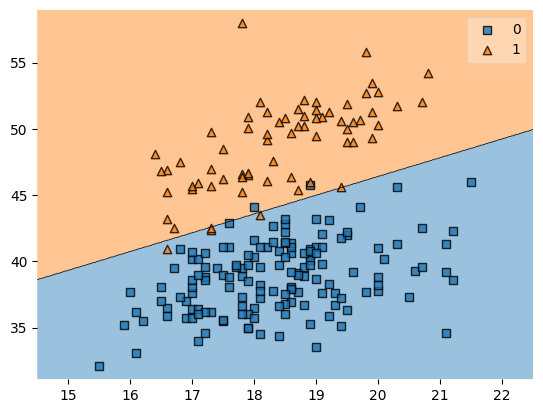

In [65]:
X_2 = df[['bill_depth_mm','bill_length_mm']].values
model_2 = sklearn.linear_model.LogisticRegression(random_state=0).fit(X_2, y)
model_2.score(X_2, y)

Using bill depth and bill length resulted in an r-squared value of 0.97. This indicates that these features are more linearly seperable.

In [69]:
X_3 = df[['flipper_length_mm', 'bill_depth_mm']].values
model_3 = sklearn.linear_model.LogisticRegression(random_state=0).fit(X_3, y)
model_3.score(X_3, y)

0.7383177570093458

Using flipper length and bill depth resulted in an r-squared value of 0.73. This indicates that they are not as good at predicting penguin species.